<a href="https://colab.research.google.com/github/arukhsarh/DH_Intership_Tasks/blob/main/Bank_Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import pandas as pd

# Creating a dummy Bank Churn dataset
data = {
    'CreditScore': np.random.randint(300, 850, 1000),
    'Geography': np.random.choice(['France', 'Germany', 'Spain'], 1000),
    'Gender': np.random.choice(['Male', 'Female'], 1000),
    'Age': np.random.randint(18, 90, 1000),
    'Tenure': np.random.randint(0, 10, 1000),
    'Balance': np.random.uniform(0, 200000, 1000),
    'NumOfProducts': np.random.randint(1, 4, 1000),
    'HasCrCard': np.random.randint(0, 2, 1000),
    'IsActiveMember': np.random.randint(0, 2, 1000),
    'EstimatedSalary': np.random.uniform(10000, 150000, 1000),
    'Exited': np.random.randint(0, 2, 1000) # This is the Target (Churn)
}

df_churn = pd.DataFrame(data)
print("Bank Dataset")
df_churn.head()

Bank Dataset


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,543,Germany,Female,23,6,167324.168156,2,1,0,40925.075956,0
1,473,Spain,Female,49,2,81396.605869,1,1,1,62026.697092,0
2,427,France,Male,84,4,79067.084119,2,0,1,43728.074545,0
3,606,Germany,Female,81,0,120954.970706,2,0,1,112907.982354,1
4,376,France,Male,42,6,130189.851488,1,1,0,83964.238742,0


In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
df_churn['Geography'] = le.fit_transform(df_churn['Geography'])
df_churn['Gender'] = le.fit_transform(df_churn['Gender'])

X = df_churn.drop('Exited', axis=1)
y = df_churn['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Encoding and Splitting!")

Encoding and Splitting!


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initializing the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Training the model
model.fit(X_train, y_train)

# Checking Accuracy
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Model Accuracy: 50.50%


/tmp/ipykernel_3586/3741013941.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette='viridis')


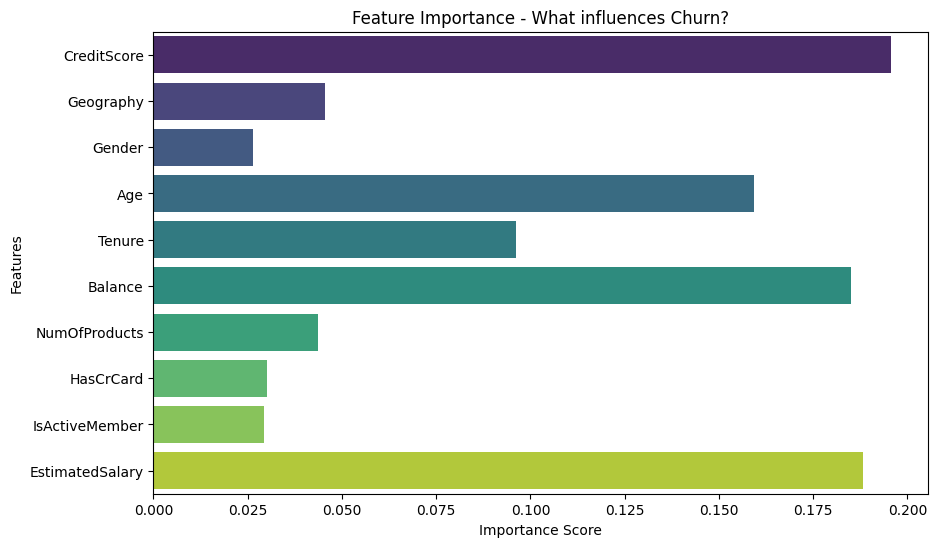

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Getting feature importances
importances = model.feature_importances_
feature_names = X.columns

# Creating a plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names, palette='viridis')
plt.title('Feature Importance - What influences Churn?')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()